# Learning-to-Rank with Pairwise Optimization (BPR)

## 1. Setup

### 1.1 Imports

In [1]:
import sys
sys.path.insert(0, '..')

import json
import pickle
import time
from pathlib import Path
from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.loader import load_ratings
from src.data.splitter import split_temporal
from src.data.adapter import DataAdapter
from src.models.bpr import BPR
from src.models.popularity import PopularityRecommender
from src.evaluation.metrics import compute_ranking_metrics, compute_beyond_accuracy_metrics

### 1.2 Constants

In [2]:
TRAIN_RATIO = 0.7
VALIDATION_RATIO = 0.15
TEST_RATIO = 0.15
IMPLICIT_THRESHOLD = 4.0
TOP_K = 10
RANDOM_SEED = 42

FACTORS = 64
LEARNING_RATE = 0.01
REGULARIZATION = 0.01
EPOCHS = 50
NEGATIVE_SAMPLES = 1
BATCH_SIZE = 2048

VALIDATION_SAMPLE_SIZE = 500
VALIDATION_EVAL_EVERY = 5

NEGATIVE_SAMPLES_SWEEP = [1, 3, 5, 10]
SWEEP_EPOCHS = 30

HEAD_FRACTION = 0.2

K_VALUES = [5, 10, 20, 50]

FIGURE_SIZE_SMALL = (8, 4)
FIGURE_SIZE_MEDIUM = (10, 6)
FIGURE_SIZE_LARGE = (12, 8)

COLOR_PRIMARY = "#4C72B0"
COLOR_SECONDARY = "#DD8452"
COLOR_TERTIARY = "#55A868"
COLOR_ACCENT = "#C44E52"

ARTIFACTS_DIRECTORY = Path('../artifacts')
ARTIFACTS_DIRECTORY.mkdir(exist_ok=True)

### 1.3 Chart style

In [3]:
def configure_plot_style():
    plt.rcParams.update({
        'figure.dpi': 150,
        'axes.grid': True,
        'grid.alpha': 0.3,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'font.size': 11,
        'axes.titlesize': 13,
        'axes.labelsize': 11,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
    })


configure_plot_style()

### 1.4 Data

In [4]:
ratings = load_ratings()

train_dataframe, validation_dataframe, test_dataframe = split_temporal(
    ratings,
    train_ratio=TRAIN_RATIO,
    validation_ratio=VALIDATION_RATIO,
    test_ratio=TEST_RATIO,
)

adapter = DataAdapter()
train_data = adapter.to_implicit(
    train_dataframe,
    threshold=IMPLICIT_THRESHOLD,
)

validation_positive = validation_dataframe[validation_dataframe['rating'] >= IMPLICIT_THRESHOLD]
validation_users = validation_positive['user_id'].unique()

test_positive = test_dataframe[test_dataframe['rating'] >= IMPLICIT_THRESHOLD]
test_users = test_positive['user_id'].unique()

pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'interactions': [len(train_dataframe), len(validation_dataframe), len(test_dataframe)],
    'positive': [train_data.X_ui.nnz, len(validation_positive), len(test_positive)],
    'users': [train_data.X_ui.shape[0], len(validation_users), len(test_users)],
})

Loaded 1000209 ratings from c:\Users\Mykyta\Projects\ucu-recsys\experiments\..\data\ml-1m\ratings.dat


,split,interactions,positive,users
0,train,700118,416338,6040
1,validation,150081,81113,5927
2,test,150010,77830,5914


## 2. BPR Training

### 2.1 Training with convergence tracking

In [5]:
np.random.seed(RANDOM_SEED)
sampled_validation_users = np.random.choice(
    validation_users,
    size=min(VALIDATION_SAMPLE_SIZE, len(validation_users)),
    replace=False,
)
sampled_validation_positive = validation_positive[
    validation_positive['user_id'].isin(sampled_validation_users)
]


def make_validation_callback(sampled_positive, sampled_users):
    def compute_validation_metrics(model, epoch):
        if (epoch + 1) % VALIDATION_EVAL_EVERY != 0:
            return {}

        recommendations = model.recommend_for_eval(
            sampled_users,
            k=TOP_K,
        )
        return compute_ranking_metrics(
            sampled_positive,
            recommendations,
            top_k=TOP_K,
        )

    return compute_validation_metrics


validation_callback = make_validation_callback(
    sampled_validation_positive,
    sampled_validation_users,
)

In [6]:
bpr_model = BPR(
    n_factors=FACTORS,
    learning_rate=LEARNING_RATE,
    reg=REGULARIZATION,
    n_epochs=EPOCHS,
    n_neg_samples=NEGATIVE_SAMPLES,
    batch_size=BATCH_SIZE,
    seed=RANDOM_SEED,
    verbose=True,
)

start_time = time.time()
bpr_model.fit(
    train_data,
    validation_callback=validation_callback,
)
training_time = time.time() - start_time

training_time

BPR Training: 100%|██████████| 50/50 [03:20<00:00,  4.02s/it, loss=0.182753, val_ndcg=0.0930]


200.901762008667

### 2.2 Training loss

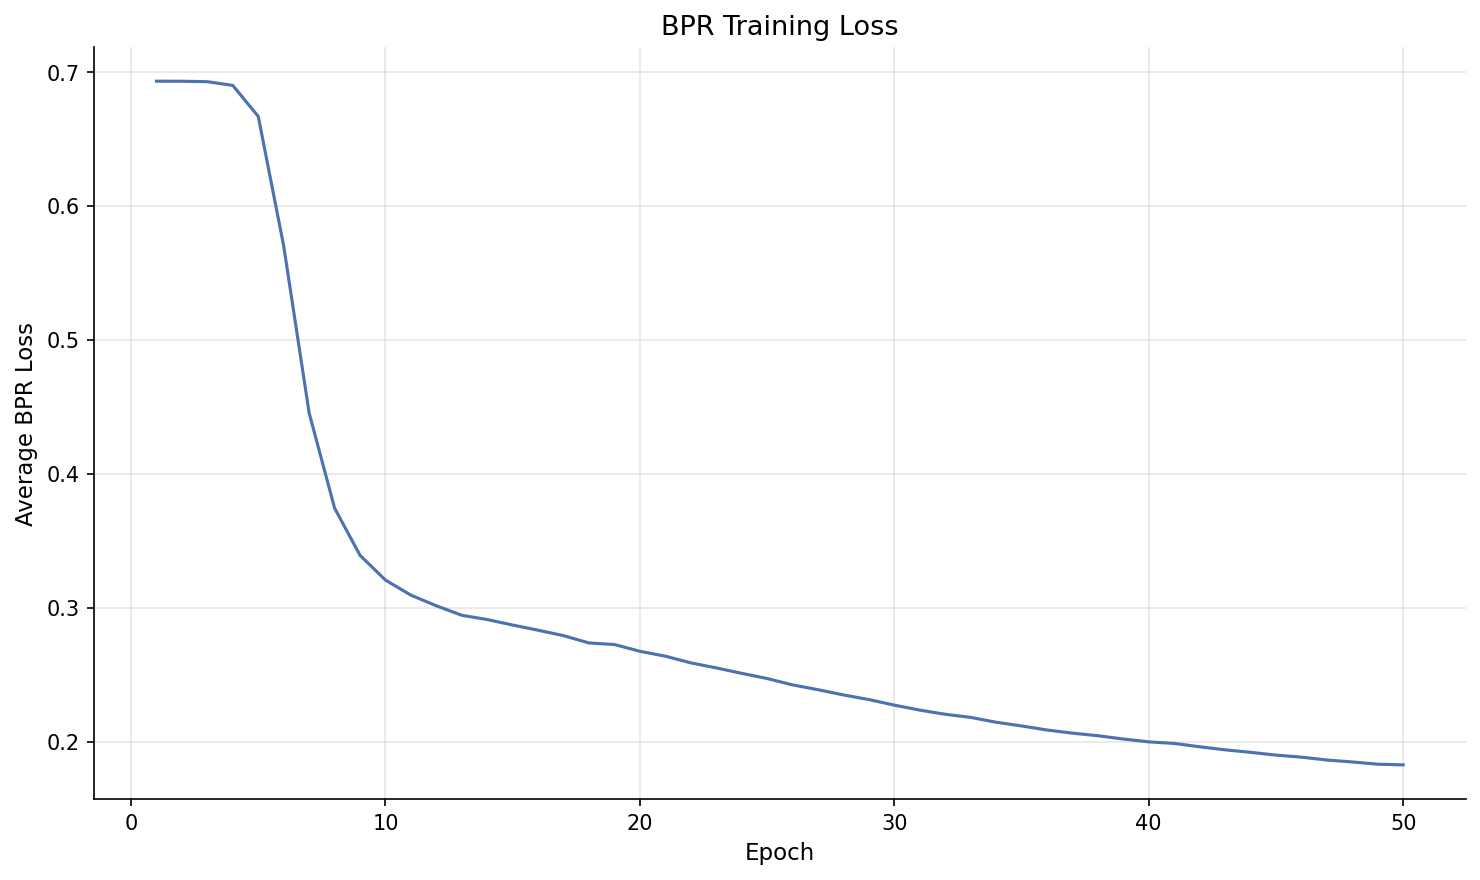

In [7]:
plt.figure(figsize=FIGURE_SIZE_MEDIUM)
plt.plot(
    range(1, len(bpr_model.training_loss_history) + 1),
    bpr_model.training_loss_history,
    color=COLOR_PRIMARY,
    linewidth=1.5,
)
plt.xlabel('Epoch')
plt.ylabel('Average BPR Loss')
plt.title('BPR Training Loss')
plt.tight_layout()
plt.show()

### 2.3 Validation NDCG

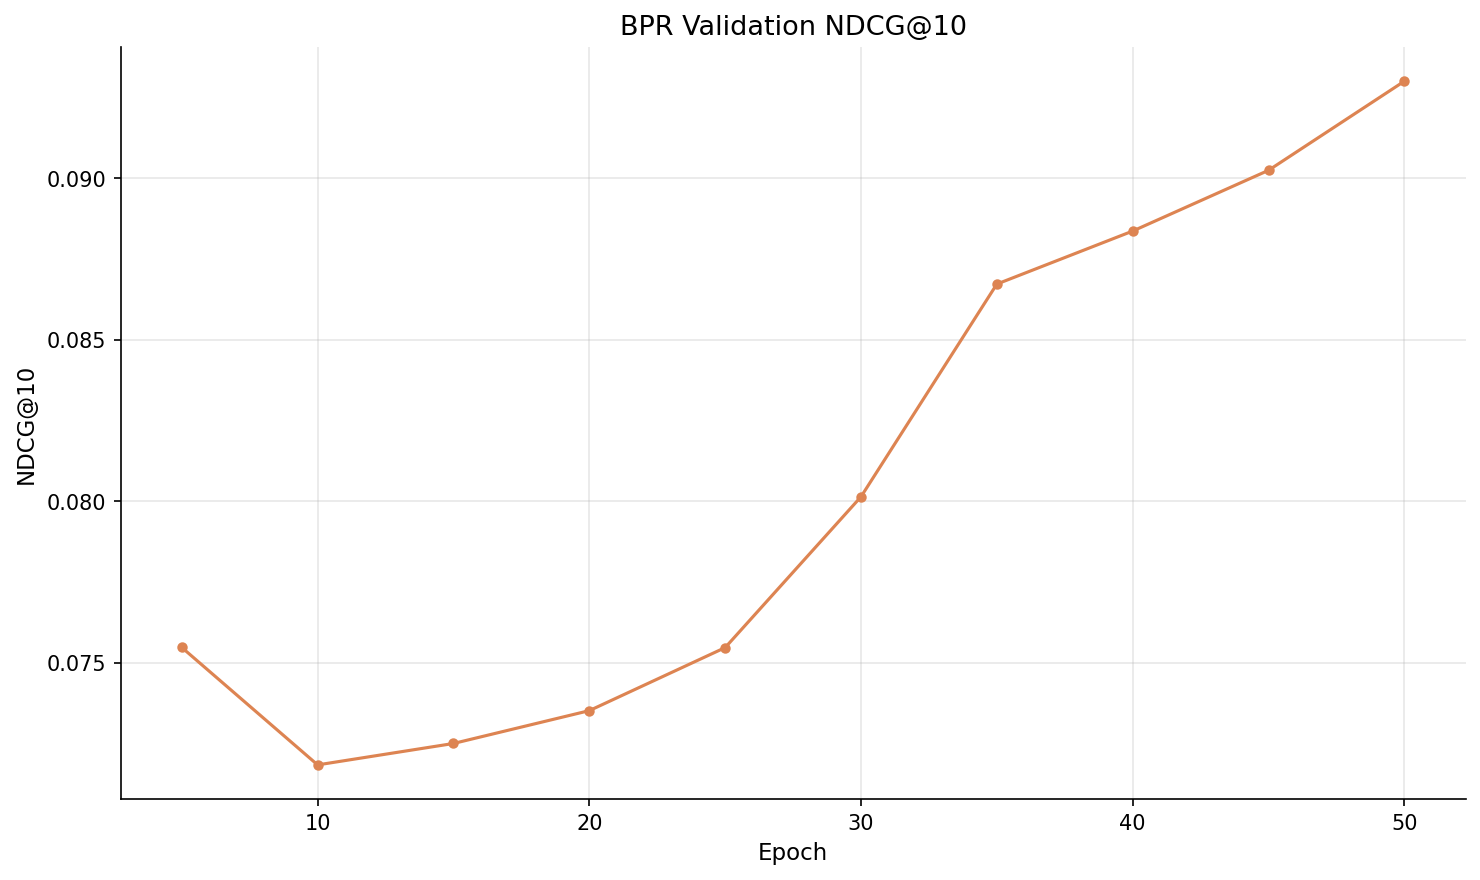

In [8]:
validation_epochs = []
validation_ndcg_values = []

for epoch_index, metrics in enumerate(bpr_model.validation_metrics_history):
    if 'ndcg' in metrics:
        validation_epochs.append(epoch_index + 1)
        validation_ndcg_values.append(metrics['ndcg'])

plt.figure(figsize=FIGURE_SIZE_MEDIUM)
plt.plot(
    validation_epochs,
    validation_ndcg_values,
    color=COLOR_SECONDARY,
    linewidth=1.5,
    marker='o',
    markersize=4,
)
plt.xlabel('Epoch')
plt.ylabel('NDCG@10')
plt.title('BPR Validation NDCG@10')
plt.tight_layout()
plt.show()

## 3. Sensitivity to Sampling

### 3.1 Sweep

In [9]:
sampling_results = []

for negative_count in tqdm(NEGATIVE_SAMPLES_SWEEP):
    model = BPR(
        n_factors=FACTORS,
        learning_rate=LEARNING_RATE,
        reg=REGULARIZATION,
        n_epochs=SWEEP_EPOCHS,
        n_neg_samples=negative_count,
        batch_size=BATCH_SIZE,
        seed=RANDOM_SEED,
        verbose=False,
    )

    start = time.time()
    model.fit(train_data)
    elapsed = time.time() - start

    recommendations = model.recommend_for_eval(
        sampled_validation_users,
        k=TOP_K,
    )
    metrics = compute_ranking_metrics(
        sampled_validation_positive,
        recommendations,
        top_k=TOP_K,
    )

    sampling_results.append({
        'negative_samples': negative_count,
        'training_time': elapsed,
        **metrics,
    })

sampling_dataframe = pd.DataFrame(sampling_results)
sampling_dataframe

100%|██████████| 4/4 [20:23<00:00, 305.90s/it]


,negative_samples,training_time,ndcg,map,precision,recall
0,1,101.393744,0.080139,0.035826,0.0686,0.057354
1,3,189.405919,0.106007,0.051993,0.0844,0.080890
2,5,315.978085,0.103627,0.051133,0.0828,0.079051
3,10,615.780262,0.117777,0.059047,0.0888,0.106611


### 3.2 NDCG by sampling count

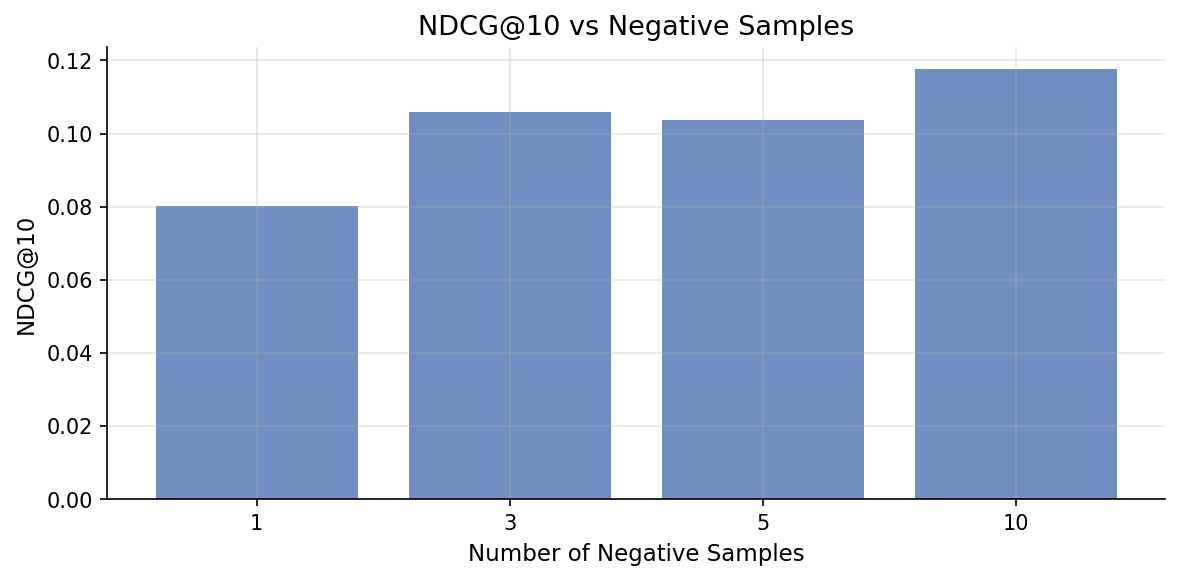

In [10]:
plt.figure(figsize=FIGURE_SIZE_SMALL)
plt.bar(
    [str(n) for n in sampling_dataframe['negative_samples']],
    sampling_dataframe['ndcg'],
    color=COLOR_PRIMARY,
    alpha=0.8,
)
plt.xlabel('Number of Negative Samples')
plt.ylabel('NDCG@10')
plt.title('NDCG@10 vs Negative Samples')
plt.tight_layout()
plt.show()

### 3.3 Recall by sampling count

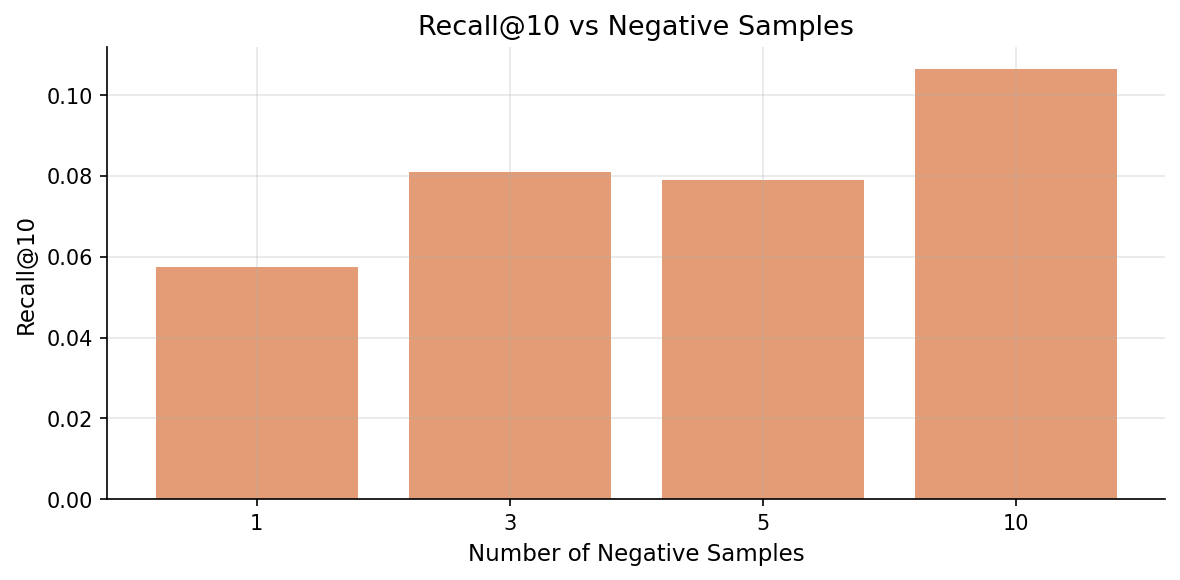

In [11]:
plt.figure(figsize=FIGURE_SIZE_SMALL)
plt.bar(
    [str(n) for n in sampling_dataframe['negative_samples']],
    sampling_dataframe['recall'],
    color=COLOR_SECONDARY,
    alpha=0.8,
)
plt.xlabel('Number of Negative Samples')
plt.ylabel('Recall@10')
plt.title('Recall@10 vs Negative Samples')
plt.tight_layout()
plt.show()

### 3.4 Training time by sampling count

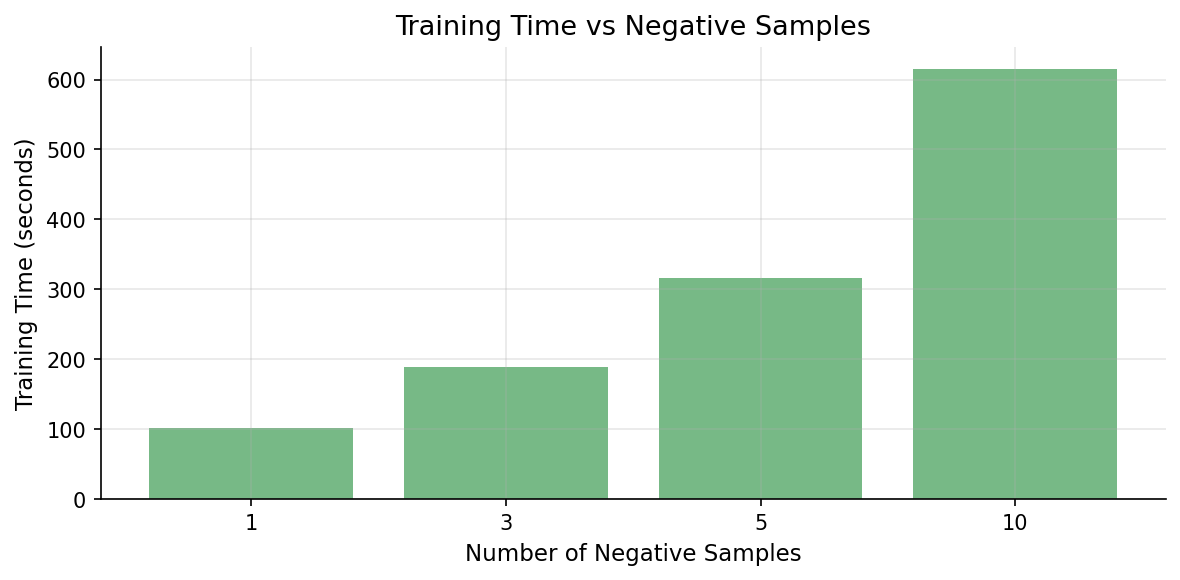

In [12]:
plt.figure(figsize=FIGURE_SIZE_SMALL)
plt.bar(
    [str(n) for n in sampling_dataframe['negative_samples']],
    sampling_dataframe['training_time'],
    color=COLOR_TERTIARY,
    alpha=0.8,
)
plt.xlabel('Number of Negative Samples')
plt.ylabel('Training Time (seconds)')
plt.title('Training Time vs Negative Samples')
plt.tight_layout()
plt.show()

## 4. Head vs Tail Items

### 4.1 Item segmentation

In [13]:
item_popularity = train_dataframe.groupby('item_id').size().reset_index(name='interaction_count')
item_popularity = item_popularity.sort_values(
    'interaction_count',
    ascending=False,
)

n_head_items = int(len(item_popularity) * HEAD_FRACTION)
head_item_ids = set(item_popularity.iloc[:n_head_items]['item_id'])
tail_item_ids = set(item_popularity.iloc[n_head_items:]['item_id'])

test_head = test_positive[test_positive['item_id'].isin(head_item_ids)]
test_tail = test_positive[test_positive['item_id'].isin(tail_item_ids)]

pd.DataFrame({
    'segment': ['head', 'tail'],
    'items': [len(head_item_ids), len(tail_item_ids)],
    'test_positives': [len(test_head), len(test_tail)],
})

,segment,items,test_positives
0,head,729,49653
1,tail,2920,28159


### 4.2 Segment evaluation

In [14]:
popularity_model = PopularityRecommender()
popularity_model.fit(train_data)

bpr_test_recommendations = bpr_model.recommend_for_eval(
    test_users,
    k=TOP_K,
)
popularity_test_recommendations = popularity_model.recommend_for_eval(
    test_users,
    k=TOP_K,
)

segment_results = []

for model_name, recommendations in [('Popularity', popularity_test_recommendations), ('BPR', bpr_test_recommendations)]:
    for segment_name, segment_test in [('all', test_positive), ('head', test_head), ('tail', test_tail)]:
        if len(segment_test) == 0:
            continue

        metrics = compute_ranking_metrics(
            segment_test,
            recommendations,
            top_k=TOP_K,
        )

        segment_results.append({
            'model': model_name,
            'segment': segment_name,
            **metrics,
        })

segment_dataframe = pd.DataFrame(segment_results)
segment_dataframe

,model,segment,ndcg,map,precision,recall
0,Popularity,all,0.063937,0.029496,0.054058,0.043244
1,Popularity,head,0.069866,0.033195,0.056345,0.057322
2,Popularity,tail,0.000000,0.000000,0.000000,0.000000
3,BPR,all,0.077443,0.035869,0.064119,0.055568
4,BPR,head,0.085686,0.040930,0.066285,0.077190
5,BPR,tail,0.000693,0.000242,0.000673,0.000532


### 4.3 NDCG by segment

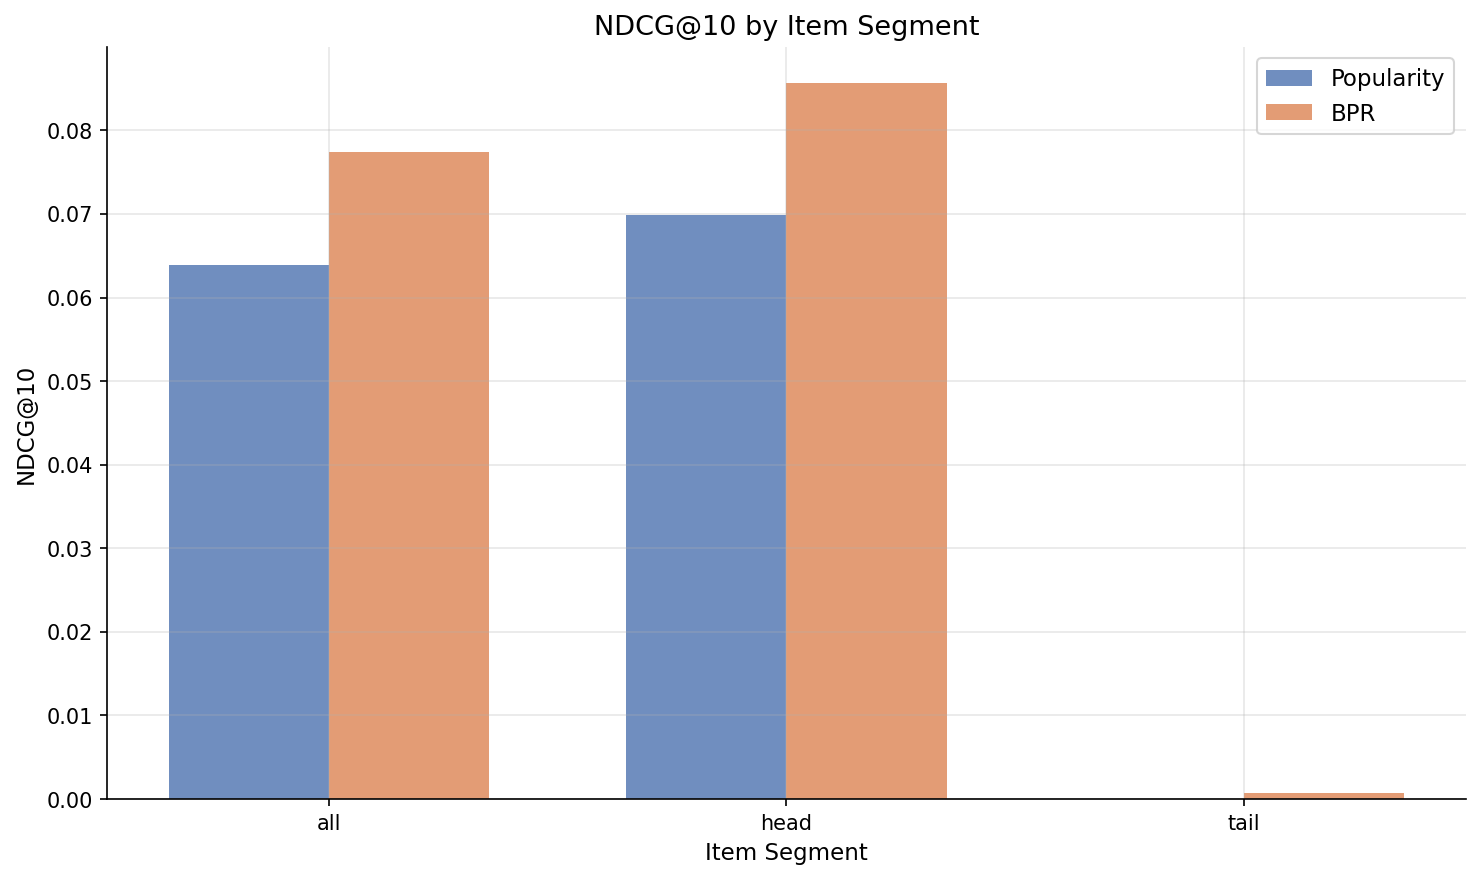

In [15]:
segments = ['all', 'head', 'tail']
bpr_ndcg = [segment_dataframe[(segment_dataframe['model'] == 'BPR') & (segment_dataframe['segment'] == s)]['ndcg'].values[0] for s in segments]
popularity_ndcg = [segment_dataframe[(segment_dataframe['model'] == 'Popularity') & (segment_dataframe['segment'] == s)]['ndcg'].values[0] for s in segments]

x_positions = np.arange(len(segments))
bar_width = 0.35

plt.figure(figsize=FIGURE_SIZE_MEDIUM)
plt.bar(
    x_positions - bar_width / 2,
    popularity_ndcg,
    width=bar_width,
    label='Popularity',
    color=COLOR_PRIMARY,
    alpha=0.8,
)
plt.bar(
    x_positions + bar_width / 2,
    bpr_ndcg,
    width=bar_width,
    label='BPR',
    color=COLOR_SECONDARY,
    alpha=0.8,
)
plt.xticks(
    x_positions,
    segments,
)
plt.xlabel('Item Segment')
plt.ylabel('NDCG@10')
plt.title('NDCG@10 by Item Segment')
plt.legend()
plt.tight_layout()
plt.show()

### 4.4 Recall by segment

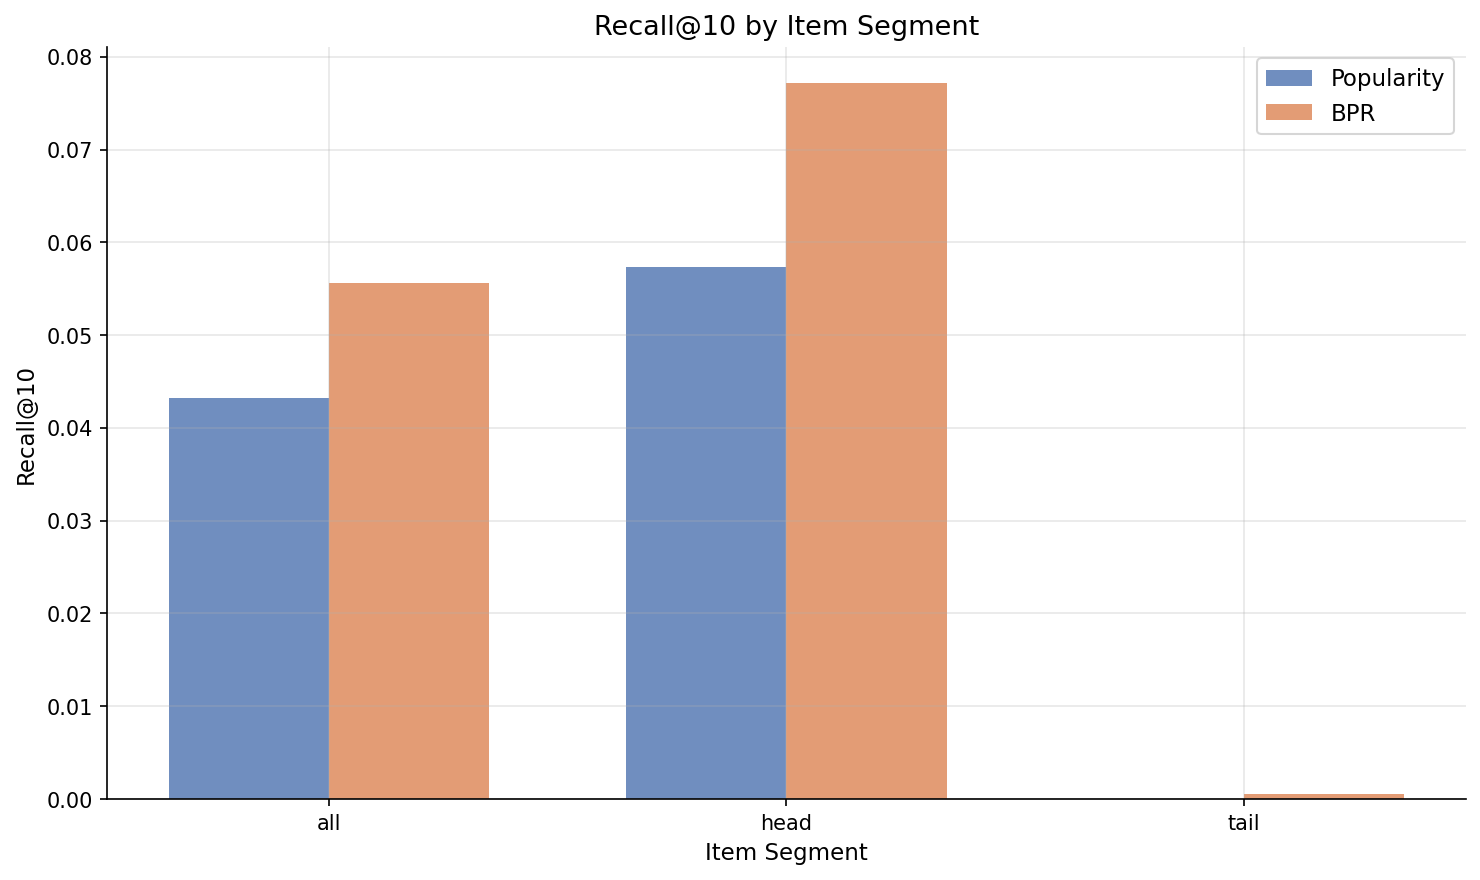

In [16]:
bpr_recall = [segment_dataframe[(segment_dataframe['model'] == 'BPR') & (segment_dataframe['segment'] == s)]['recall'].values[0] for s in segments]
popularity_recall = [segment_dataframe[(segment_dataframe['model'] == 'Popularity') & (segment_dataframe['segment'] == s)]['recall'].values[0] for s in segments]

plt.figure(figsize=FIGURE_SIZE_MEDIUM)
plt.bar(
    x_positions - bar_width / 2,
    popularity_recall,
    width=bar_width,
    label='Popularity',
    color=COLOR_PRIMARY,
    alpha=0.8,
)
plt.bar(
    x_positions + bar_width / 2,
    bpr_recall,
    width=bar_width,
    label='BPR',
    color=COLOR_SECONDARY,
    alpha=0.8,
)
plt.xticks(
    x_positions,
    segments,
)
plt.xlabel('Item Segment')
plt.ylabel('Recall@10')
plt.title('Recall@10 by Item Segment')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Comparison with Popularity

### 5.1 Final test evaluation

In [17]:
bpr_ranking = compute_ranking_metrics(
    test_positive,
    bpr_test_recommendations,
    top_k=TOP_K,
)
popularity_ranking = compute_ranking_metrics(
    test_positive,
    popularity_test_recommendations,
    top_k=TOP_K,
)

comparison_dataframe = pd.DataFrame([
    {'model': 'Popularity', **popularity_ranking},
    {'model': 'BPR', **bpr_ranking},
])

comparison_dataframe

,model,ndcg,map,precision,recall
0,Popularity,0.063937,0.029496,0.054058,0.043244
1,BPR,0.077443,0.035869,0.064119,0.055568


### 5.2 NDCG at K

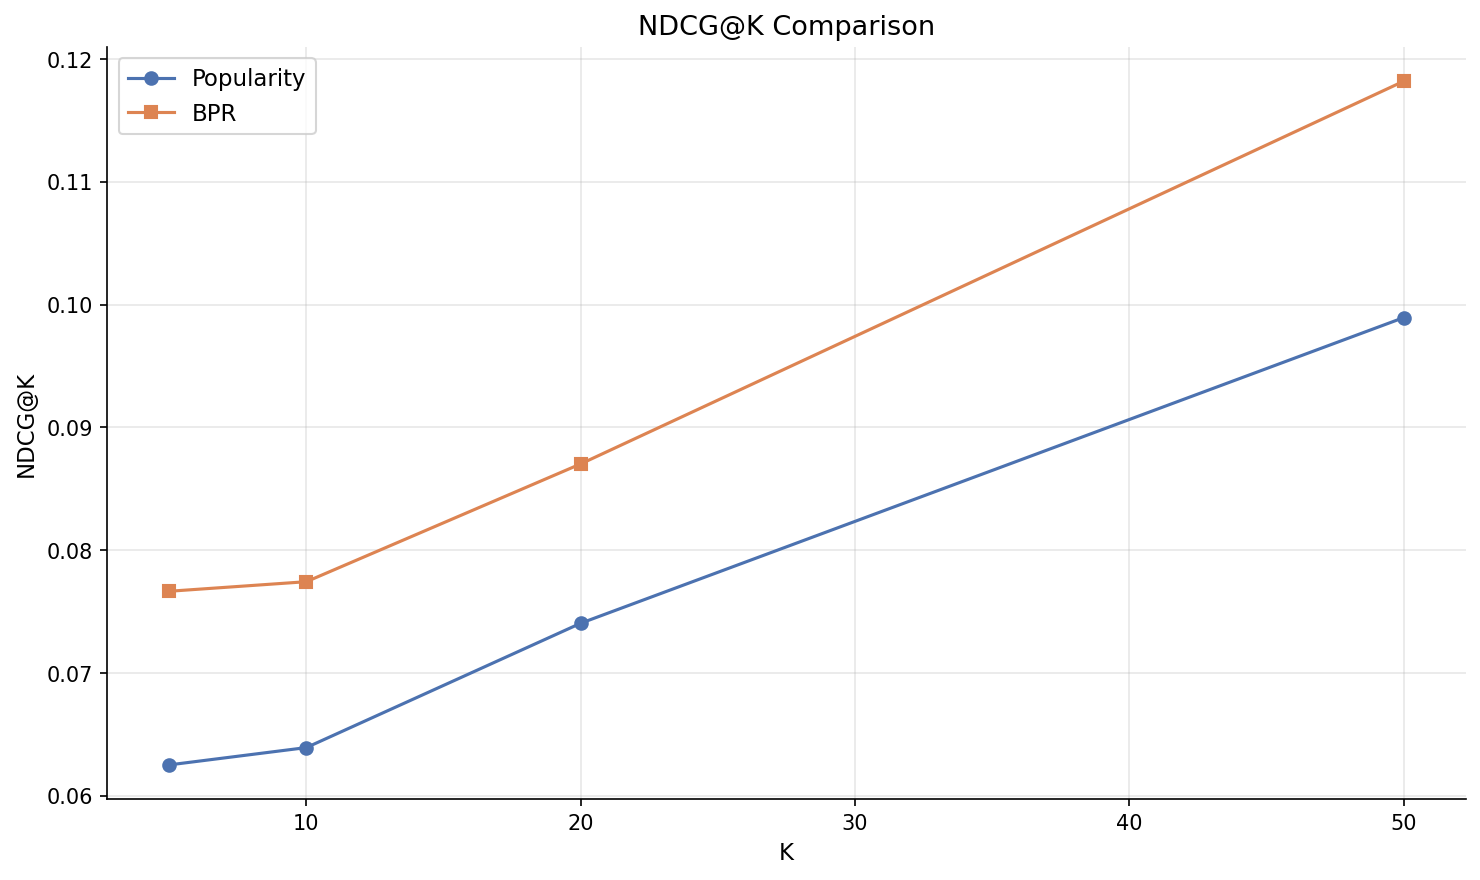

In [18]:
bpr_ndcg_at_k = []
popularity_ndcg_at_k = []

for k in K_VALUES:
    bpr_recs = bpr_model.recommend_for_eval(
        test_users,
        k=k,
    )
    pop_recs = popularity_model.recommend_for_eval(
        test_users,
        k=k,
    )

    bpr_metrics = compute_ranking_metrics(
        test_positive,
        bpr_recs,
        top_k=k,
    )
    pop_metrics = compute_ranking_metrics(
        test_positive,
        pop_recs,
        top_k=k,
    )

    bpr_ndcg_at_k.append(bpr_metrics['ndcg'])
    popularity_ndcg_at_k.append(pop_metrics['ndcg'])

plt.figure(figsize=FIGURE_SIZE_MEDIUM)
plt.plot(
    K_VALUES,
    popularity_ndcg_at_k,
    marker='o',
    label='Popularity',
    color=COLOR_PRIMARY,
    linewidth=1.5,
)
plt.plot(
    K_VALUES,
    bpr_ndcg_at_k,
    marker='s',
    label='BPR',
    color=COLOR_SECONDARY,
    linewidth=1.5,
)
plt.xlabel('K')
plt.ylabel('NDCG@K')
plt.title('NDCG@K Comparison')
plt.legend()
plt.tight_layout()
plt.show()

### 5.3 Recall at K

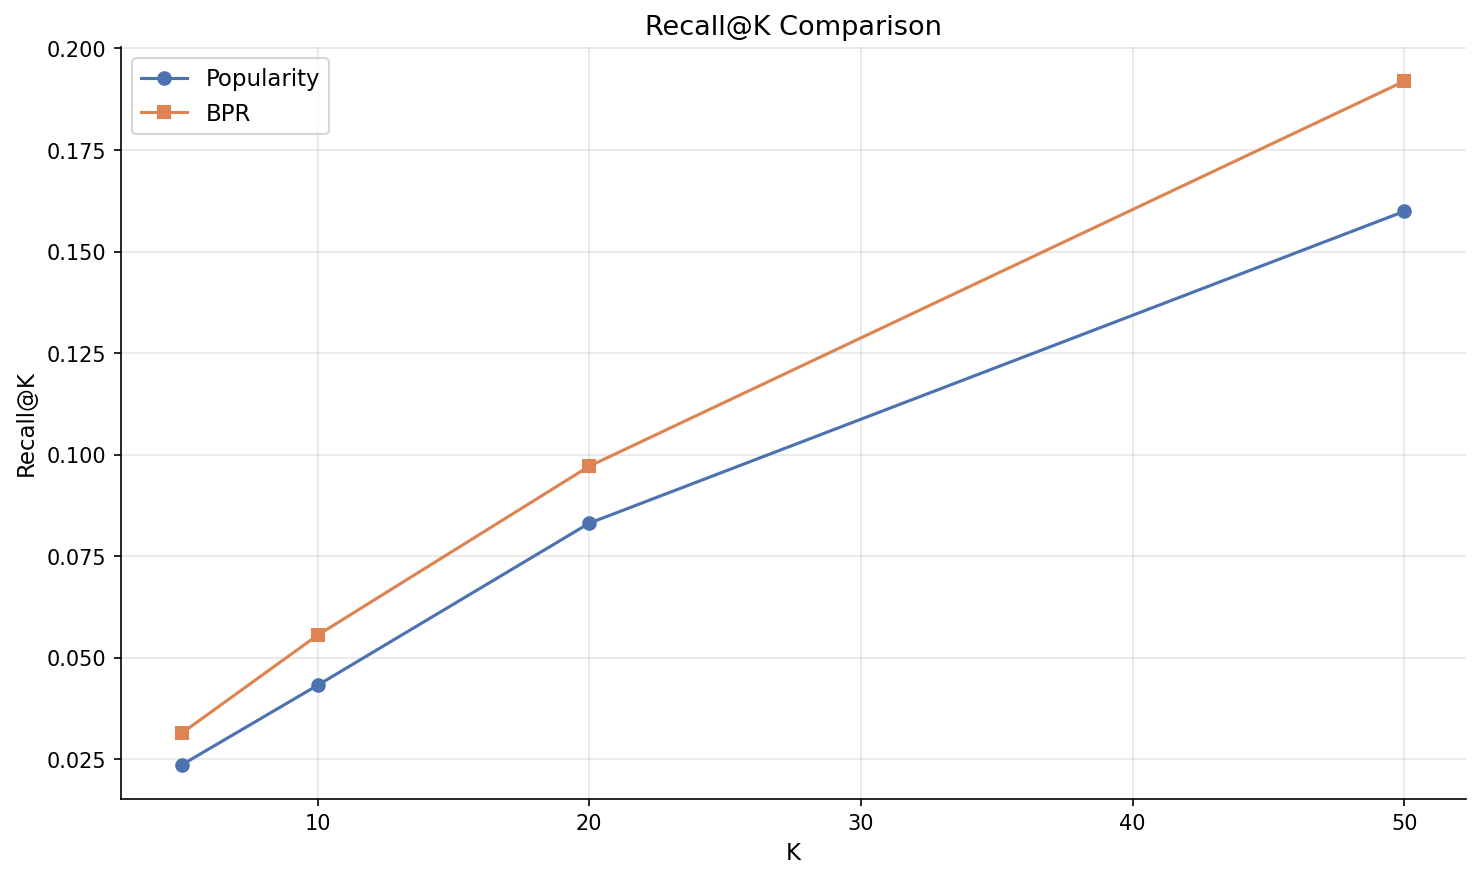

In [19]:
bpr_recall_at_k = []
popularity_recall_at_k = []

for k in K_VALUES:
    bpr_recs = bpr_model.recommend_for_eval(
        test_users,
        k=k,
    )
    pop_recs = popularity_model.recommend_for_eval(
        test_users,
        k=k,
    )

    bpr_metrics = compute_ranking_metrics(
        test_positive,
        bpr_recs,
        top_k=k,
    )
    pop_metrics = compute_ranking_metrics(
        test_positive,
        pop_recs,
        top_k=k,
    )

    bpr_recall_at_k.append(bpr_metrics['recall'])
    popularity_recall_at_k.append(pop_metrics['recall'])

plt.figure(figsize=FIGURE_SIZE_MEDIUM)
plt.plot(
    K_VALUES,
    popularity_recall_at_k,
    marker='o',
    label='Popularity',
    color=COLOR_PRIMARY,
    linewidth=1.5,
)
plt.plot(
    K_VALUES,
    bpr_recall_at_k,
    marker='s',
    label='BPR',
    color=COLOR_SECONDARY,
    linewidth=1.5,
)
plt.xlabel('K')
plt.ylabel('Recall@K')
plt.title('Recall@K Comparison')
plt.legend()
plt.tight_layout()
plt.show()

### 5.4 Beyond-accuracy metrics

In [20]:
bpr_beyond = compute_beyond_accuracy_metrics(
    train_dataframe,
    bpr_test_recommendations,
)
popularity_beyond = compute_beyond_accuracy_metrics(
    train_dataframe,
    popularity_test_recommendations,
)

pd.DataFrame([
    {'model': 'Popularity', **popularity_beyond},
    {'model': 'BPR', **bpr_beyond},
])

c:\Users\Mykyta\Projects\ucu-recsys\.venv\Lib\site-packages\recommenders\evaluation\python_evaluation.py:1435: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  avg_novelty = reco_item_novelty.agg({"product": "sum"})[0] / n_recommendations
c:\Users\Mykyta\Projects\ucu-recsys\.venv\Lib\site-packages\recommenders\evaluation\python_evaluation.py:1435: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  avg_novelty = reco_item_novelty.agg({"product": "sum"})[0] / n_recommendations


,model,coverage,novelty
0,Popularity,0.030693,8.365441
1,BPR,0.193478,8.769604


## 6. Artifacts

In [21]:
with open(ARTIFACTS_DIRECTORY / 'bpr_best.pkl', 'wb') as file:
    pickle.dump(bpr_model, file)

params_to_save = {
    'best_params': {
        'n_factors': FACTORS,
        'learning_rate': LEARNING_RATE,
        'reg': REGULARIZATION,
        'n_epochs': EPOCHS,
        'n_neg_samples': NEGATIVE_SAMPLES,
        'batch_size': BATCH_SIZE,
    },
    'test_ranking_metrics': bpr_ranking,
    'popularity_test_metrics': popularity_ranking,
}

with open(ARTIFACTS_DIRECTORY / 'bpr_params.json', 'w') as file:
    json.dump(
        params_to_save,
        file,
        indent=2,
    )

sampling_dataframe.to_csv(
    ARTIFACTS_DIRECTORY / 'bpr_sampling_sensitivity.csv',
    index=False,
)